<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Uso_Prophet_en_airpassengers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instalar Prophet
!pip -q install prophet

In [2]:
!wget -O air_passengers.csv https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv

--2026-07-10 23:15:53--  https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2180 (2.1K) [text/plain]
Saving to: ‘air_passengers.csv’

air_passengers.csv  100%[===================>]   2.13K  --.-KB/s    in 0s      

2026-07-10 23:15:53 (27.2 MB/s) - ‘air_passengers.csv’ saved [2180/2180]



In [3]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

In [4]:
# Leer datos

df = pd.read_csv("air_passengers.csv")

# Prophet necesita columnas llamadas ds y y

df.columns = ["ds", "y"]

# Convertir fechas

df["ds"] = pd.to_datetime(df["ds"])

df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [5]:
# Crear el modelo

model = Prophet()

# Entrenar

model.fit(df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [6]:
# Crear 24 meses hacia el futuro

future = model.make_future_dataframe(periods=24, freq="MS")

future.tail()

,ds
163,1962-08-01
164,1962-09-01
165,1962-10-01
166,1962-11-01
167,1962-12-01


In [7]:
# Pronóstico

forecast = model.predict(future)

forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
163,1962-08-01,614.163646,585.129334,644.209424
164,1962-09-01,566.250438,537.612849,593.895243
165,1962-10-01,530.554746,500.924323,559.159903
166,1962-11-01,497.714461,469.340152,526.179435
167,1962-12-01,527.239014,497.169366,554.755601


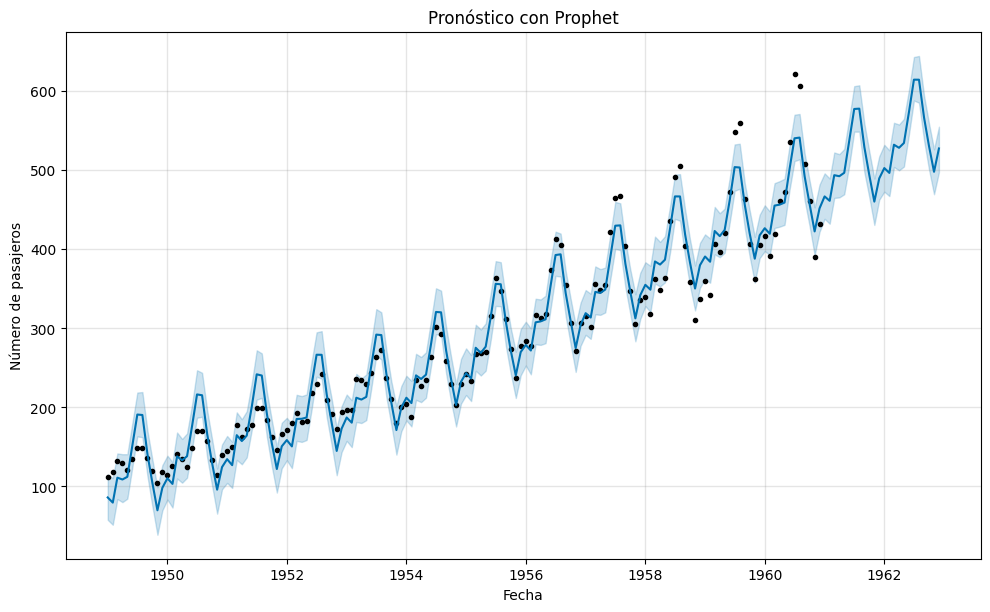

In [8]:
fig = model.plot(forecast)

plt.title("Pronóstico con Prophet")

plt.xlabel("Fecha")

plt.ylabel("Número de pasajeros")

plt.grid(True)

plt.show()

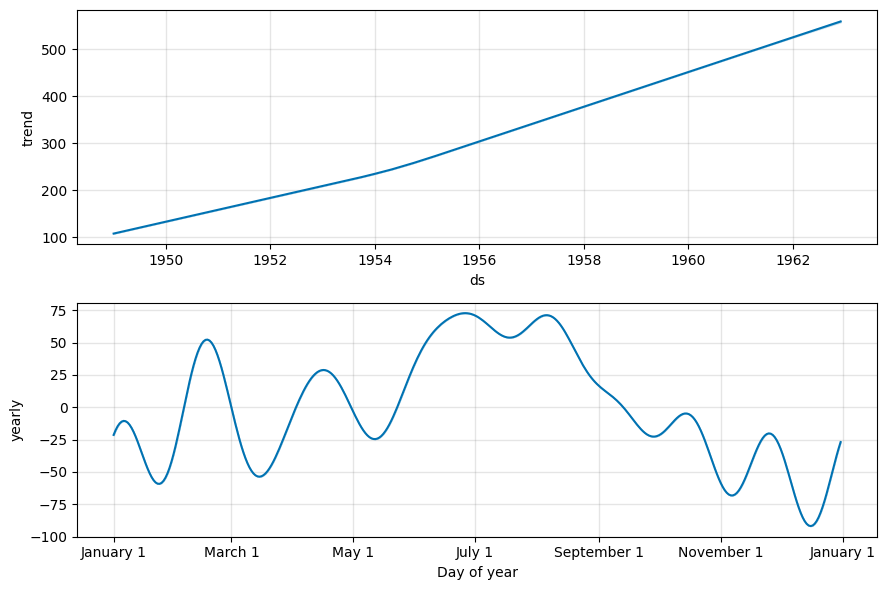

In [9]:
fig = model.plot_components(forecast)

plt.show()

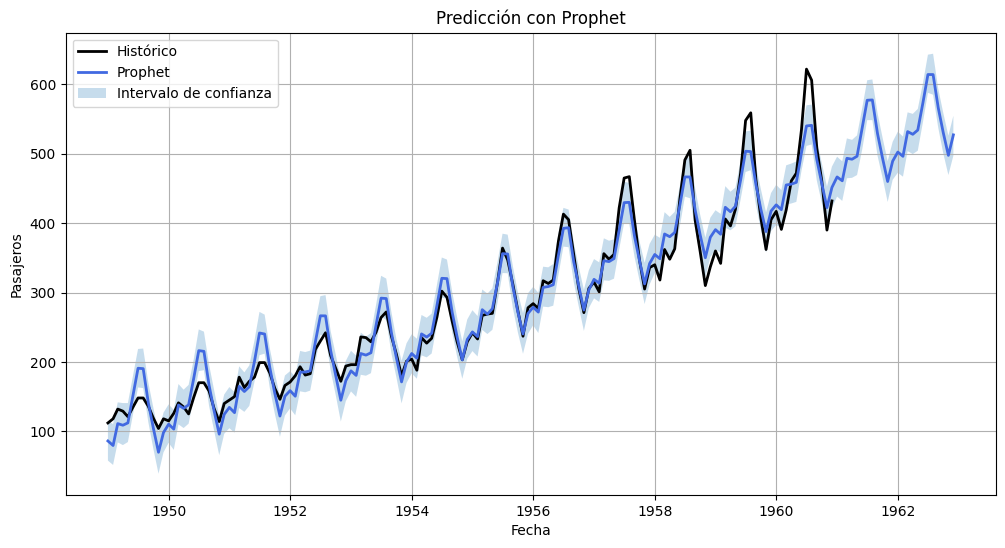

In [10]:
plt.figure(figsize=(12,6))

# Histórico
plt.plot(
    df["ds"],
    df["y"],
    color="black",
    linewidth=2,
    label="Histórico"
)

# Pronóstico
plt.plot(
    forecast["ds"],
    forecast["yhat"],
    color="royalblue",
    linewidth=2,
    label="Prophet"
)

# Intervalo de confianza
plt.fill_between(
    forecast["ds"],
    forecast["yhat_lower"],
    forecast["yhat_upper"],
    alpha=0.25,
    label="Intervalo de confianza"
)

plt.title("Predicción con Prophet")

plt.xlabel("Fecha")

plt.ylabel("Pasajeros")

plt.grid(True)

plt.legend()

plt.show()